<a href="https://colab.research.google.com/github/sacheeag/sachee-agarwal/blob/main/phase_1_sachee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# ============================================================
# PHASE 1 - EXPLORATORY DATA ANALYSIS
#
# Name       : Sachee Agarwal
# Reg No     : 23BDS0087
# Dataset    : Benefits.csv
#
# Objective:
# Perform Exploratory Data Analysis (EDA) on the Benefits dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [38]:
# Load the dataset directly from GitHub

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Benefits.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [39]:
# Display first five records of the dataset

df.head()



,rownames,stateur,statemb,state,age,tenure,joblost,nwhite,school12,sex,bluecol,smsa,married,dkids,dykids,yrdispl,rr,head,ui
0,1,4.5,167,42,49,21,other,no,no,male,yes,yes,no,no,no,7,0.290631,yes,yes
1,2,10.5,251,55,26,2,slack_work,no,no,male,yes,yes,no,yes,yes,10,0.520202,yes,no
2,3,7.2,260,21,40,19,other,no,yes,female,yes,yes,yes,no,no,10,0.432490,yes,yes
3,4,5.8,245,56,51,17,slack_work,yes,no,female,yes,yes,yes,no,no,10,0.500000,no,yes
4,5,6.5,125,58,33,1,slack_work,no,yes,male,yes,yes,yes,yes,yes,4,0.390625,yes,no


In [40]:
# Display the number of rows and columns

print("Shape of Dataset:", df.shape)



Shape of Dataset: (4877, 19)


In [41]:
# Display all column names

print(df.columns)



Index(['rownames', 'stateur', 'statemb', 'state', 'age', 'tenure', 'joblost',
       'nwhite', 'school12', 'sex', 'bluecol', 'smsa', 'married', 'dkids',
       'dykids', 'yrdispl', 'rr', 'head', 'ui'],
      dtype='object')


In [42]:
# Display information about dataset
# including datatype and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4877 entries, 0 to 4876
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  4877 non-null   int64  
 1   stateur   4877 non-null   float64
 2   statemb   4877 non-null   int64  
 3   state     4877 non-null   int64  
 4   age       4877 non-null   int64  
 5   tenure    4877 non-null   int64  
 6   joblost   4877 non-null   object 
 7   nwhite    4877 non-null   object 
 8   school12  4877 non-null   object 
 9   sex       4877 non-null   object 
 10  bluecol   4877 non-null   object 
 11  smsa      4877 non-null   object 
 12  married   4877 non-null   object 
 13  dkids     4877 non-null   object 
 14  dykids    4877 non-null   object 
 15  yrdispl   4877 non-null   int64  
 16  rr        4877 non-null   float64
 17  head      4877 non-null   object 
 18  ui        4877 non-null   object 
dtypes: float64(2), int64(6), object(11)
memory usage: 724.1+ KB


In [43]:
# Generate statistical summary of numerical columns

df.describe(include='all')

# Count missing values in each column

df.isnull().sum()




,0
rownames,0
stateur,0
statemb,0
state,0
age,0
tenure,0
joblost,0
nwhite,0
school12,0
sex,0


In [44]:
# Separate numerical and categorical columns

numerical = df.select_dtypes(include=np.number).columns

categorical = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:")
print(numerical)

print("\nCategorical Columns:")
print(categorical)


Numerical Columns:
Index(['rownames', 'stateur', 'statemb', 'state', 'age', 'tenure', 'yrdispl',
       'rr'],
      dtype='object')

Categorical Columns:
Index(['joblost', 'nwhite', 'school12', 'sex', 'bluecol', 'smsa', 'married',
       'dkids', 'dykids', 'head', 'ui'],
      dtype='object')


In [45]:
# Count duplicate records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [46]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

# Reset index after removing duplicates

df.reset_index(drop=True, inplace=True)

print("Duplicate rows removed.")

Duplicate rows removed.


In [47]:
# Display data types of all columns

df.dtypes

,0
rownames,int64
stateur,float64
statemb,int64
state,int64
age,int64
tenure,int64
joblost,object
nwhite,object
school12,object
sex,object


In [48]:
# Import LabelEncoder for converting categorical data
# into numerical values

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Encode all categorical columns

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


In [49]:
# Display transformed dataset

df.head()

,rownames,stateur,statemb,state,age,tenure,joblost,nwhite,school12,sex,bluecol,smsa,married,dkids,dykids,yrdispl,rr,head,ui
0,1,4.5,167,42,49,21,0,0,0,1,0,1,0,0,0,7,0.290631,1,1
1,2,10.5,251,55,26,2,3,0,0,1,0,1,0,1,1,10,0.520202,1,0
2,3,7.2,260,21,40,19,0,0,1,0,0,1,1,0,0,10,0.432490,1,1
3,4,5.8,245,56,51,17,3,1,0,0,0,1,1,0,0,10,0.500000,0,1
4,5,6.5,125,58,33,1,3,0,1,1,0,1,1,1,1,4,0.390625,1,0


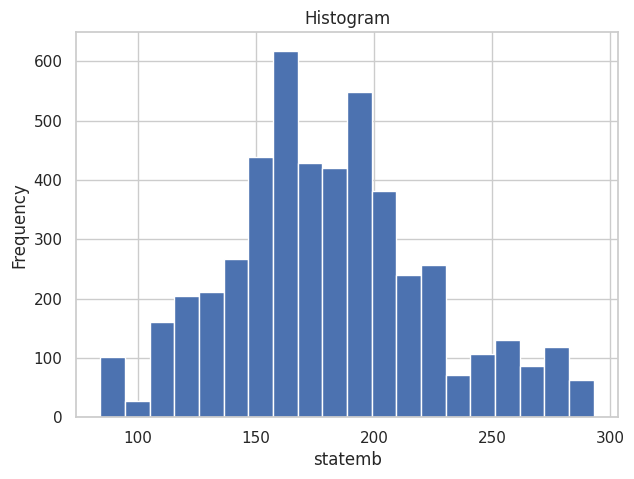

In [50]:
# Histogram shows frequency distribution
# of a numerical variable

plt.figure(figsize=(7,5))

plt.hist(df[numerical[2]], bins=20)

plt.title("Histogram")

plt.xlabel(numerical[2])

plt.ylabel("Frequency")

plt.show()

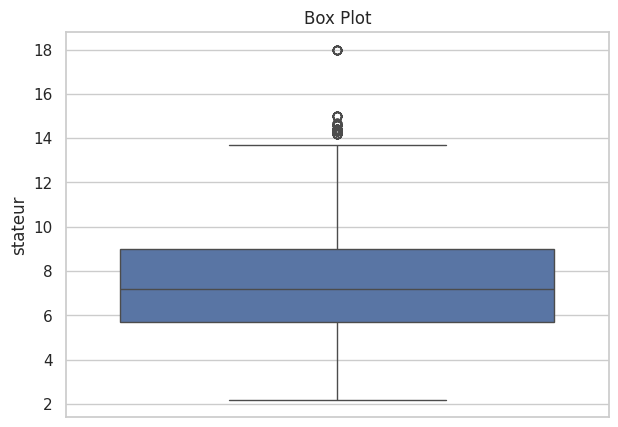

In [51]:
# Box plot is used to identify outliers

plt.figure(figsize=(7,5))

sns.boxplot(y=df[numerical[1]])

plt.title("Box Plot")

plt.show()

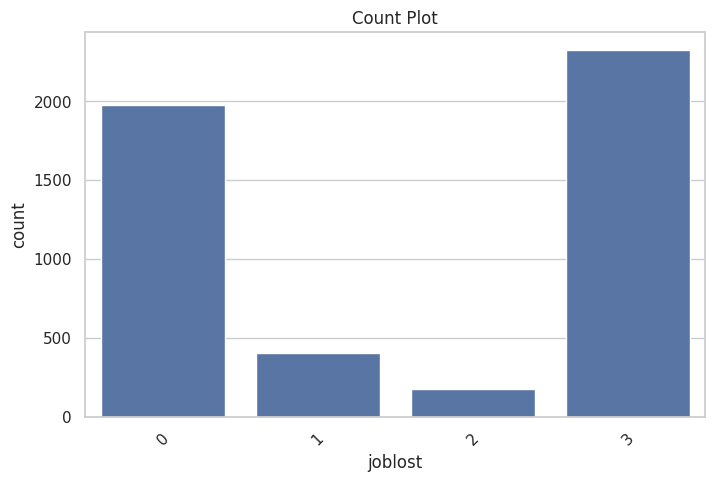

In [52]:
# Count plot displays frequency
# of each category

plt.figure(figsize=(8,5))

sns.countplot(x=df[categorical[0]])

plt.title("Count Plot")

plt.xticks(rotation=45)

plt.show()

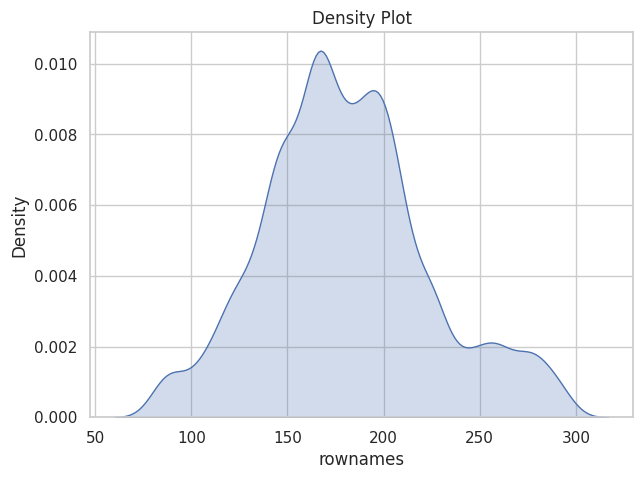

In [53]:
# Density Plot
# Displays the distribution and density of a numerical variable

plt.figure(figsize=(7,5))

sns.kdeplot(df[numerical[2]], fill=True)

plt.title("Density Plot")

plt.xlabel(numerical[0])

plt.ylabel("Density")

plt.show()

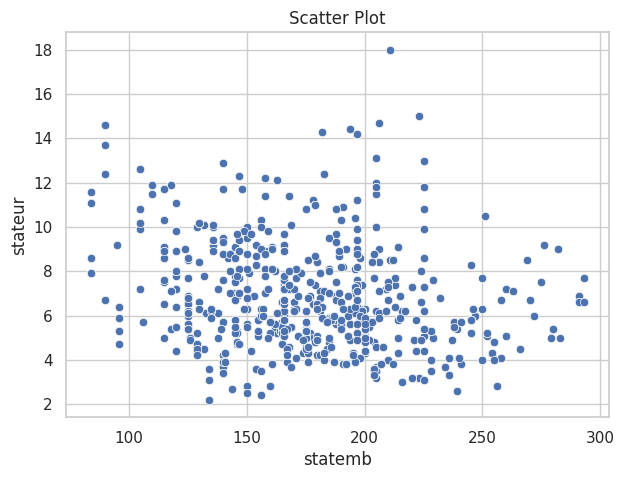

In [54]:
# Scatter plot shows relationship
# between two numerical variables

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df[numerical[2]],
    y=df[numerical[1]]
)

plt.title("Scatter Plot")

plt.show()

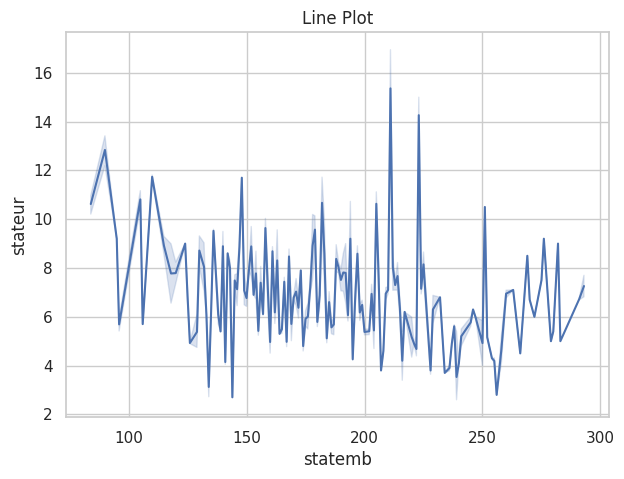

In [55]:
# Line plot displays trend
# between two numerical variables

plt.figure(figsize=(7,5))

sns.lineplot(
    x=df[numerical[2]],
    y=df[numerical[1]]
)

plt.title("Line Plot")

plt.show()

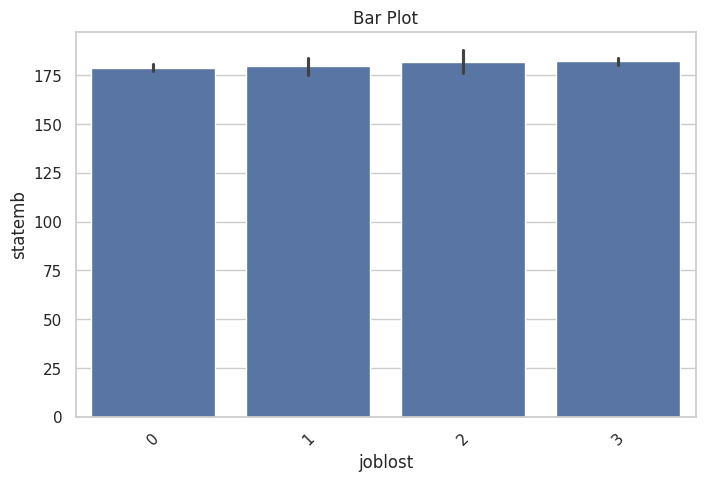

In [56]:
# Bar plot compares numerical values
# across different categories

plt.figure(figsize=(8,5))

sns.barplot(
    x=df[categorical[0]],
    y=df[numerical[2]]
)

plt.title("Bar Plot")

plt.xticks(rotation=45)

plt.show()

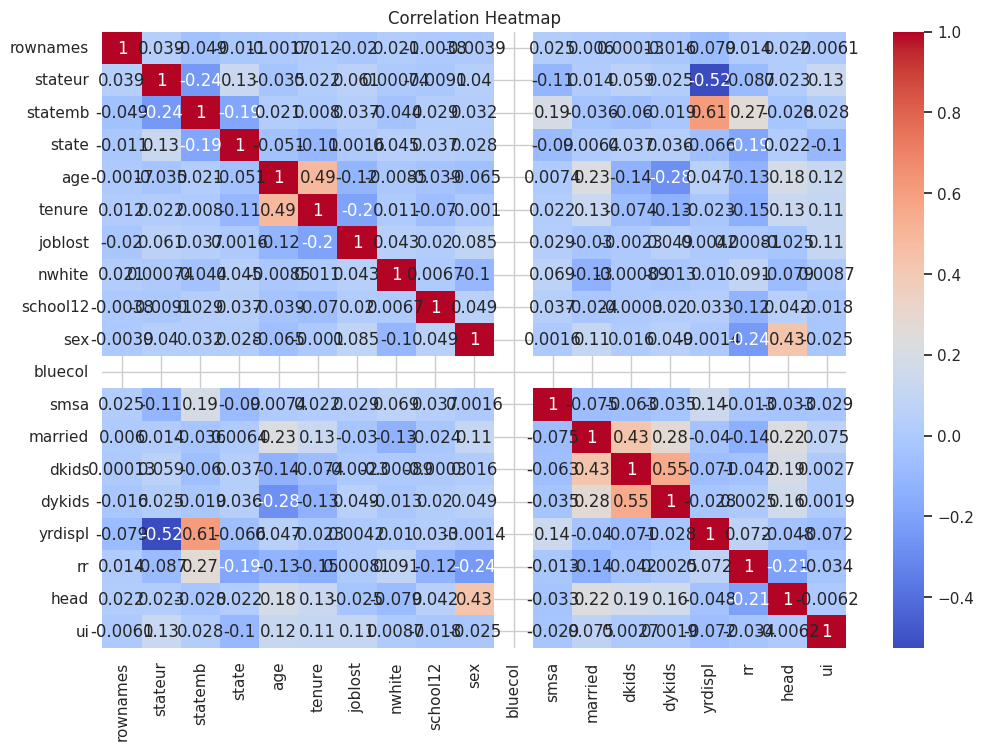

In [57]:
# Heatmap displays correlation
# between numerical variables

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

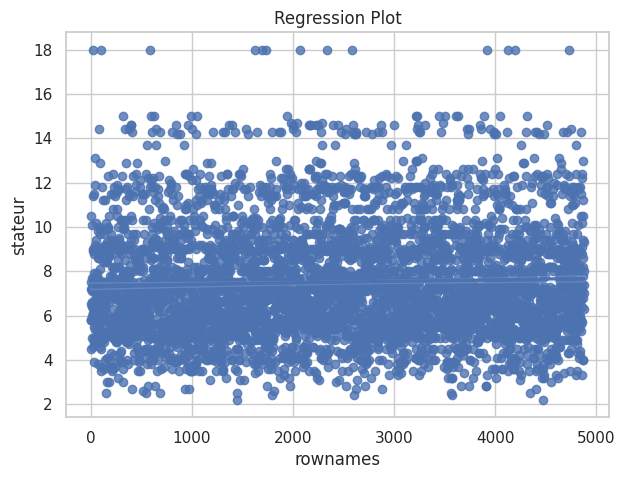

In [58]:
# Regression Plot
# Shows the relationship between two numerical variables
# along with the best-fit regression line

plt.figure(figsize=(7,5))

sns.regplot(
    x=df[numerical[0]],
    y=df[numerical[1]]
)

plt.title("Regression Plot")

plt.show()

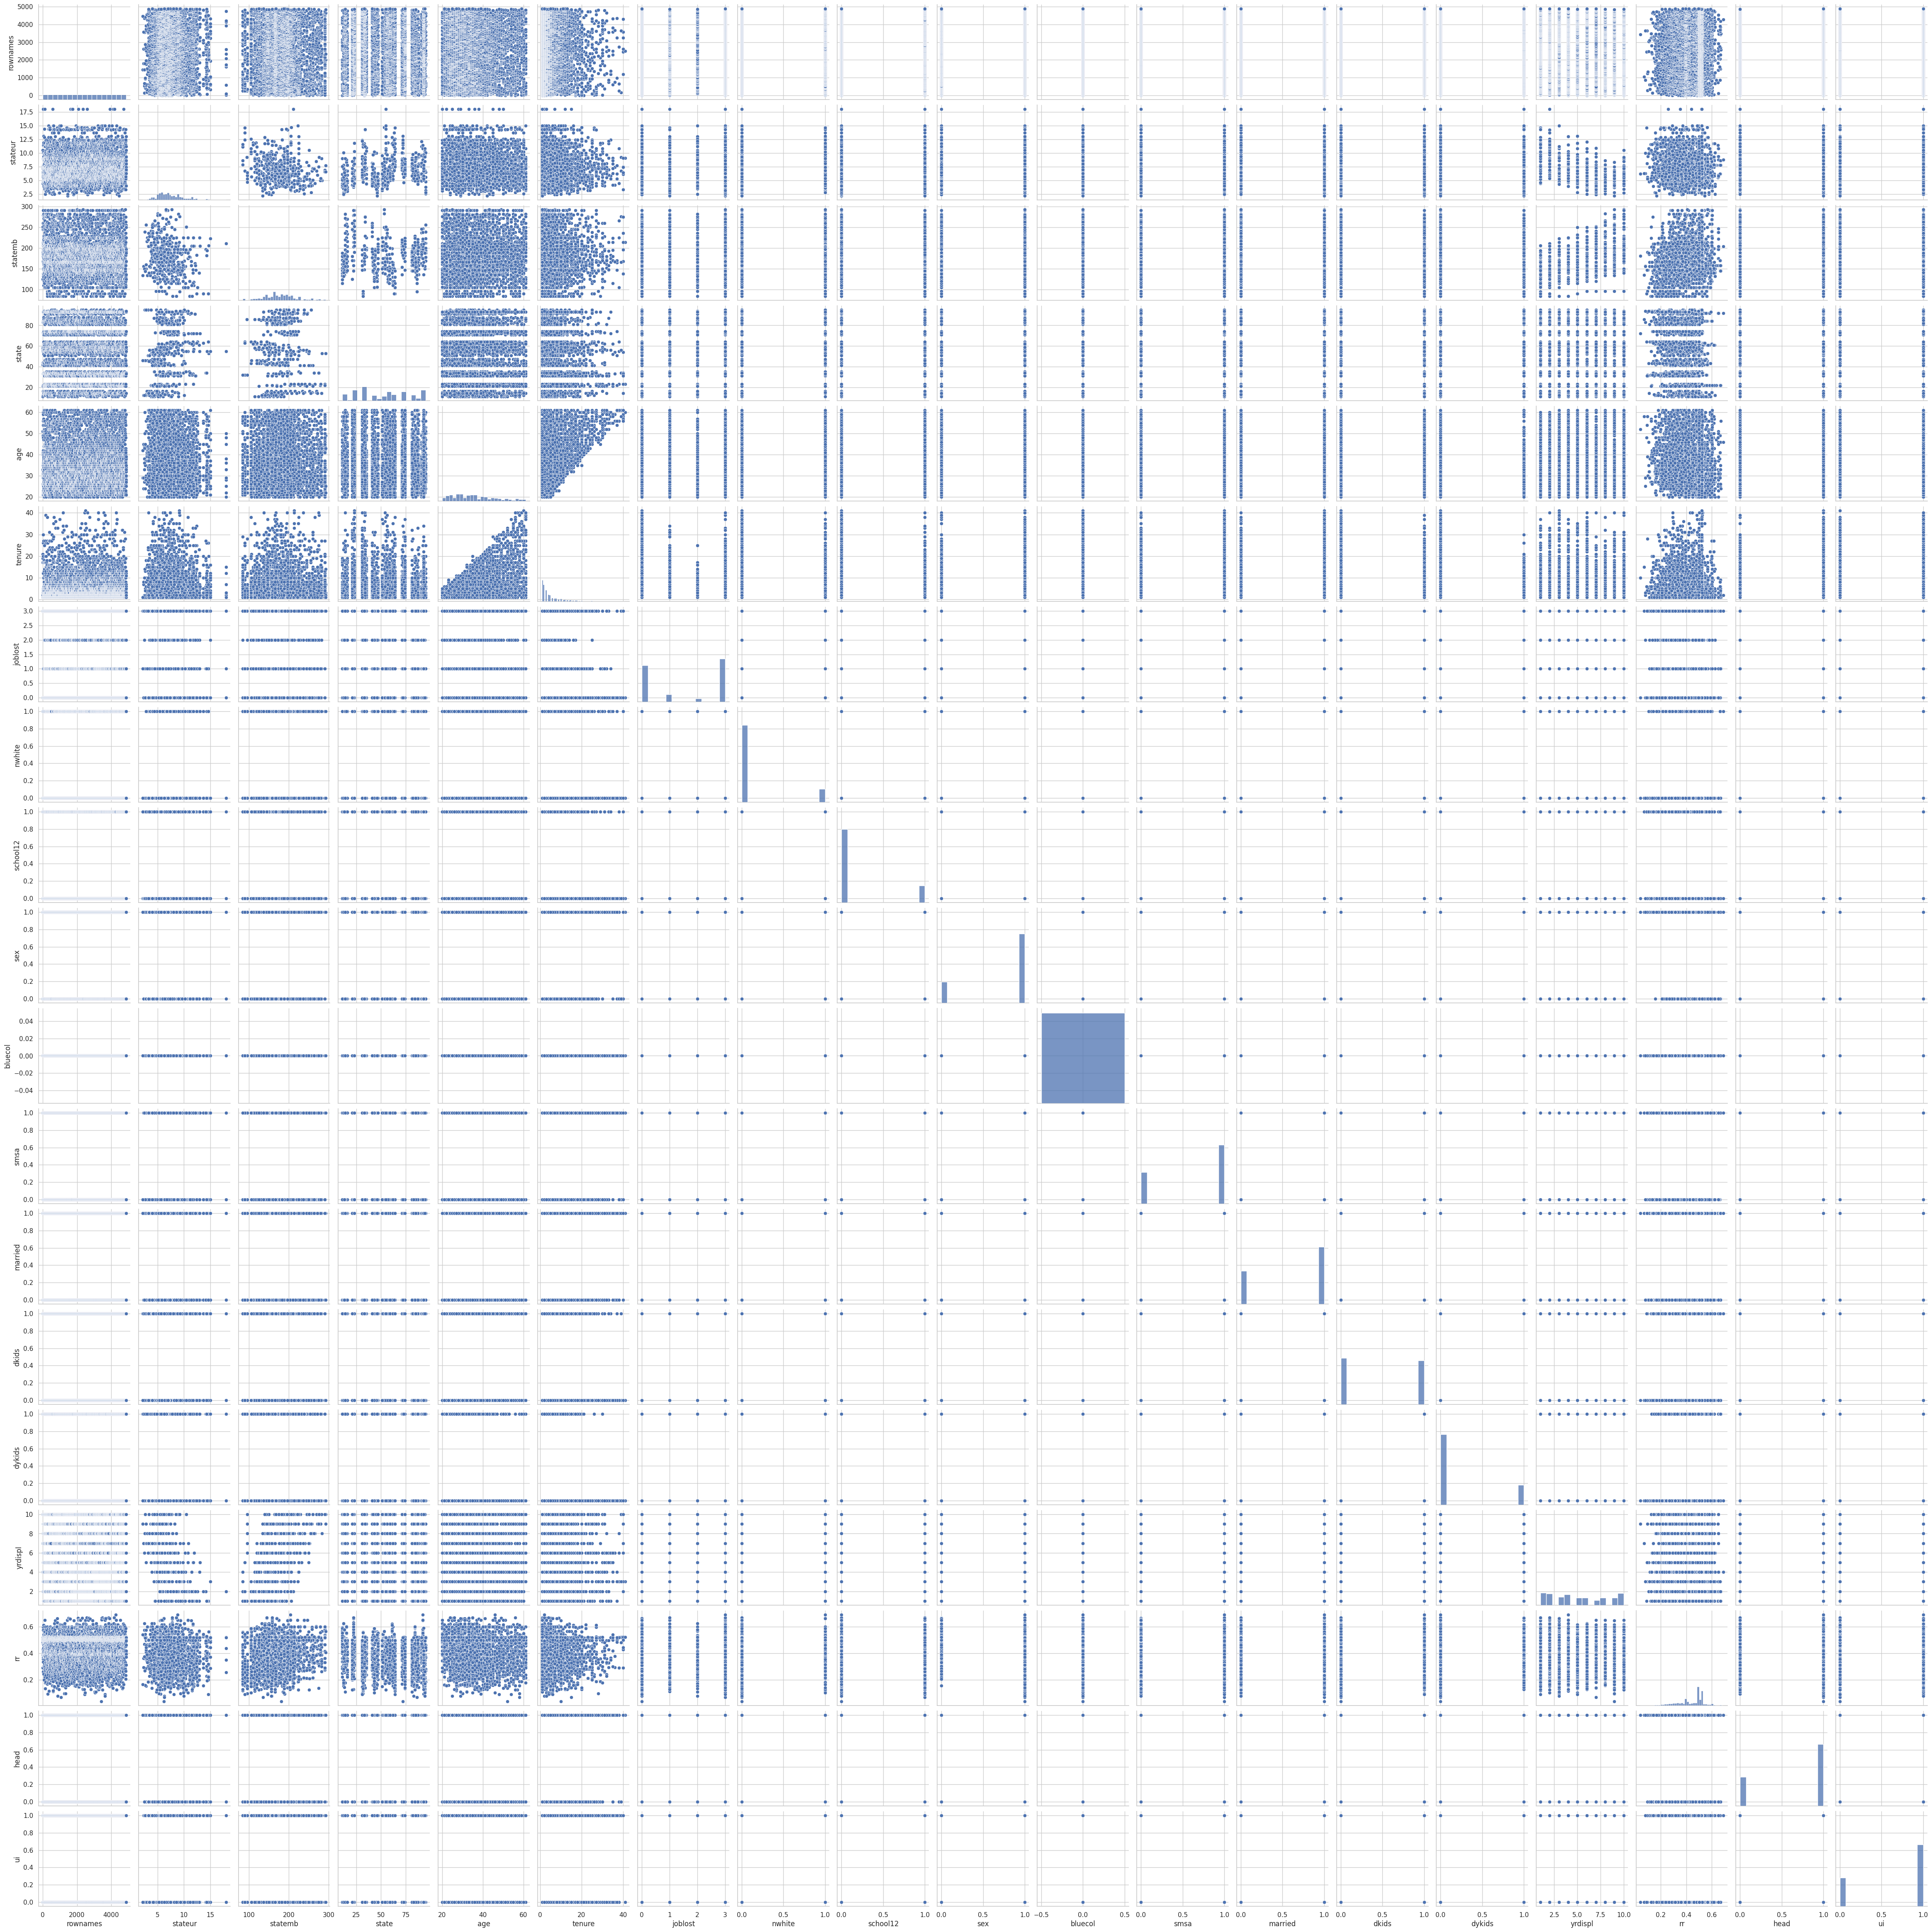

In [59]:
# Pair plot shows relationships
# among all numerical variables

sns.pairplot(df)

plt.show()

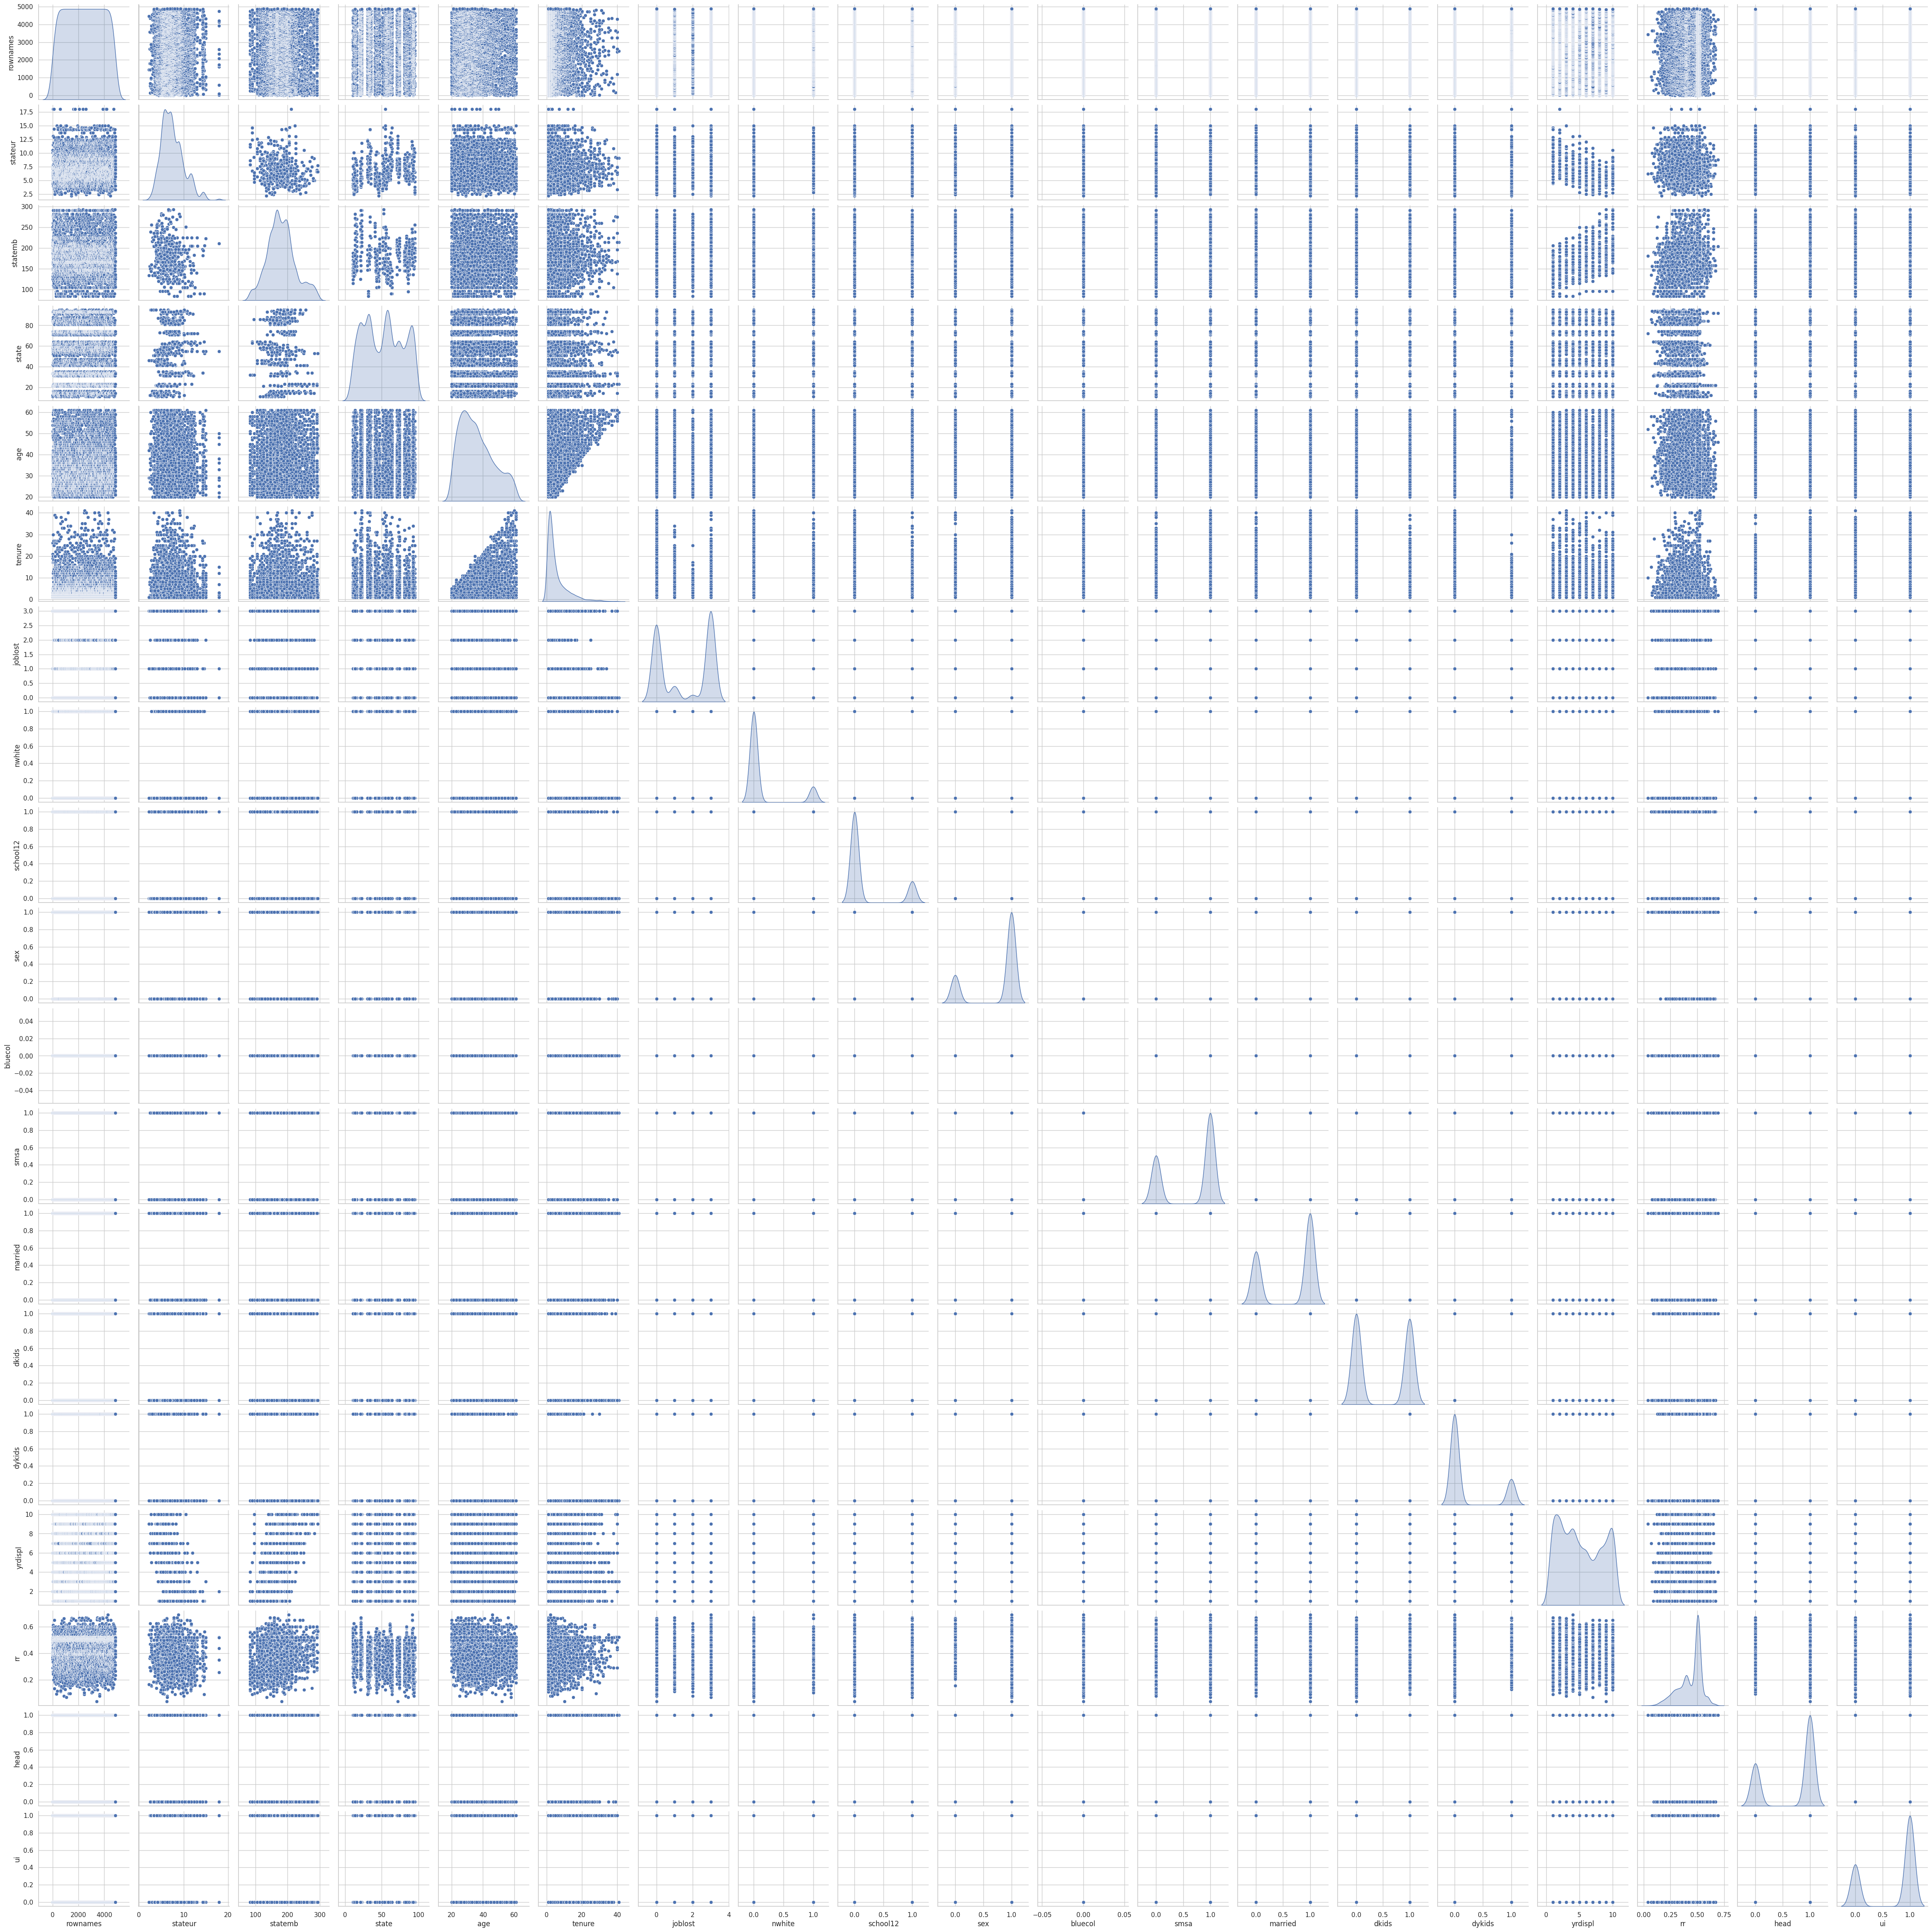

In [60]:
# Pair plot with KDE shows
# distribution along the diagonal

sns.pairplot(
    df,
    diag_kind="kde"
)

plt.show()

In [61]:
# Display cleaned and transformed dataset

df.head()

,rownames,stateur,statemb,state,age,tenure,joblost,nwhite,school12,sex,bluecol,smsa,married,dkids,dykids,yrdispl,rr,head,ui
0,1,4.5,167,42,49,21,0,0,0,1,0,1,0,0,0,7,0.290631,1,1
1,2,10.5,251,55,26,2,3,0,0,1,0,1,0,1,1,10,0.520202,1,0
2,3,7.2,260,21,40,19,0,0,1,0,0,1,1,0,0,10,0.432490,1,1
3,4,5.8,245,56,51,17,3,1,0,0,0,1,1,0,0,10,0.500000,0,1
4,5,6.5,125,58,33,1,3,0,1,1,0,1,1,1,1,4,0.390625,1,0


In [62]:
# Display cleaned and transformed dataset

df.head()

,rownames,stateur,statemb,state,age,tenure,joblost,nwhite,school12,sex,bluecol,smsa,married,dkids,dykids,yrdispl,rr,head,ui
0,1,4.5,167,42,49,21,0,0,0,1,0,1,0,0,0,7,0.290631,1,1
1,2,10.5,251,55,26,2,3,0,0,1,0,1,0,1,1,10,0.520202,1,0
2,3,7.2,260,21,40,19,0,0,1,0,0,1,1,0,0,10,0.432490,1,1
3,4,5.8,245,56,51,17,3,1,0,0,0,1,1,0,0,10,0.500000,0,1
4,5,6.5,125,58,33,1,3,0,1,1,0,1,1,1,1,4,0.390625,1,0


In [63]:
# Save cleaned dataset as CSV

df.to_csv("Benefits_Cleaned.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [64]:
# Display completion message

print("====================================")
print("Phase 1 Completed Successfully")
print("Name    : Sachee Agarwal")
print("Reg No. : 23BDS0087")
print("====================================")

Phase 1 Completed Successfully
Name    : Sachee Agarwal
Reg No. : 23BDS0087
